In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

correct_constraints = [0] * X.shape[1]
for feat, direction in {'mean radius': -1, 'worst radius': -1, 
                         'mean concave points': -1, 'worst concave points': -1}.items():
    correct_constraints[list(data.feature_names).index(feat)] = direction

In [3]:
# --- Experiment 1: Introduce missing values at increasing rates ---
# HistGradientBoosting natively handles NaN, which makes this clean to test

missing_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
results_missing = {'rate': [], 'constrained': [], 'unconstrained': []}

for rate in missing_rates:
    # Randomly set values to NaN in the training data
    X_train_noisy = X_train.copy()
    mask = np.random.RandomState(42).random(X_train_noisy.shape) < rate
    X_train_noisy[mask] = np.nan
    
    for name, cst in [('constrained', correct_constraints), ('unconstrained', None)]:
        model = HistGradientBoostingClassifier(monotonic_cst=cst, max_iter=200, random_state=42)
        model.fit(X_train_noisy, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results_missing['rate'].append(rate)
        results_missing[name] = results_missing.get(name, [])
        # (fix the storage — accumulate per model)
    
    # Simpler approach:
    model_c = HistGradientBoostingClassifier(monotonic_cst=correct_constraints, max_iter=200, random_state=42)
    model_u = HistGradientBoostingClassifier(max_iter=200, random_state=42)
    model_c.fit(X_train_noisy, y_train)
    model_u.fit(X_train_noisy, y_train)
    results_missing['rate'].append(rate)
    results_missing['constrained'].append(accuracy_score(y_test, model_c.predict(X_test)))
    results_missing['unconstrained'].append(accuracy_score(y_test, model_u.predict(X_test)))

# Fix: the list accumulation above has a bug from the loop structure.
# Here's the clean version:
results_clean = {'rate': [], 'constrained': [], 'unconstrained': []}
for rate in missing_rates:
    X_train_noisy = X_train.copy()
    mask = np.random.RandomState(42).random(X_train_noisy.shape) < rate
    X_train_noisy[mask] = np.nan
    
    model_c = HistGradientBoostingClassifier(monotonic_cst=correct_constraints, max_iter=200, random_state=42)
    model_u = HistGradientBoostingClassifier(max_iter=200, random_state=42)
    model_c.fit(X_train_noisy, y_train)
    model_u.fit(X_train_noisy, y_train)
    results_clean['rate'].append(rate)
    results_clean['constrained'].append(accuracy_score(y_test, model_c.predict(X_test)))
    results_clean['unconstrained'].append(accuracy_score(y_test, model_u.predict(X_test)))

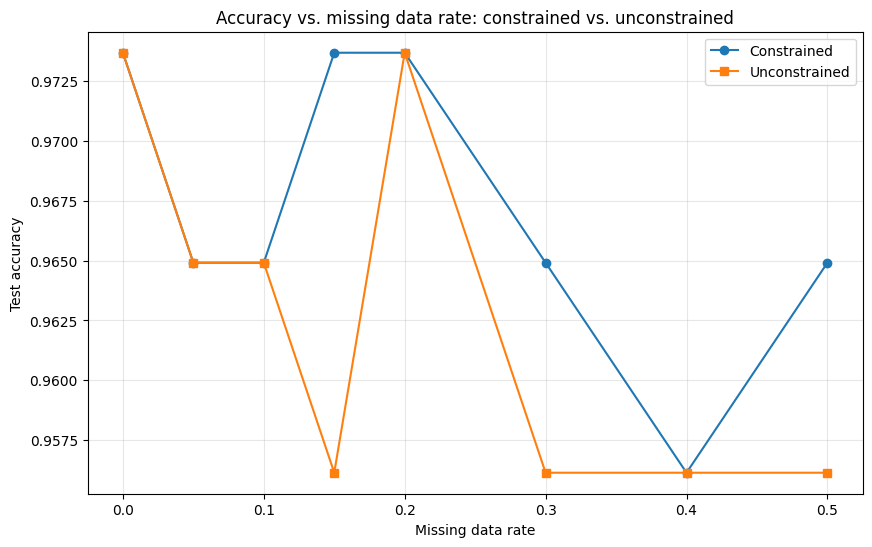

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(results_clean['rate'], results_clean['constrained'], 'o-', label='Constrained')
plt.plot(results_clean['rate'], results_clean['unconstrained'], 's-', label='Unconstrained')
plt.xlabel('Missing data rate')
plt.ylabel('Test accuracy')
plt.title('Accuracy vs. missing data rate: constrained vs. unconstrained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('missing_data_robustness.png', dpi=150)

In [5]:
# --- Experiment 2: Feature noise ---
# Add Gaussian noise to specific features at increasing levels
noise_levels = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0]
results_noise = {'level': [], 'constrained': [], 'unconstrained': []}

for noise in noise_levels:
    X_train_noisy = X_train.copy()
    # Add noise to the constrained features specifically
    for feat in ['mean radius', 'worst radius', 'mean concave points', 'worst concave points']:
        idx = list(data.feature_names).index(feat)
        std = X_train.iloc[:, idx].std()
        X_train_noisy.iloc[:, idx] += np.random.RandomState(42).normal(0, noise * std, len(X_train))
    
    model_c = HistGradientBoostingClassifier(monotonic_cst=correct_constraints, max_iter=200, random_state=42)
    model_u = HistGradientBoostingClassifier(max_iter=200, random_state=42)
    model_c.fit(X_train_noisy, y_train)
    model_u.fit(X_train_noisy, y_train)
    results_noise['level'].append(noise)
    results_noise['constrained'].append(accuracy_score(y_test, model_c.predict(X_test)))
    results_noise['unconstrained'].append(accuracy_score(y_test, model_u.predict(X_test)))

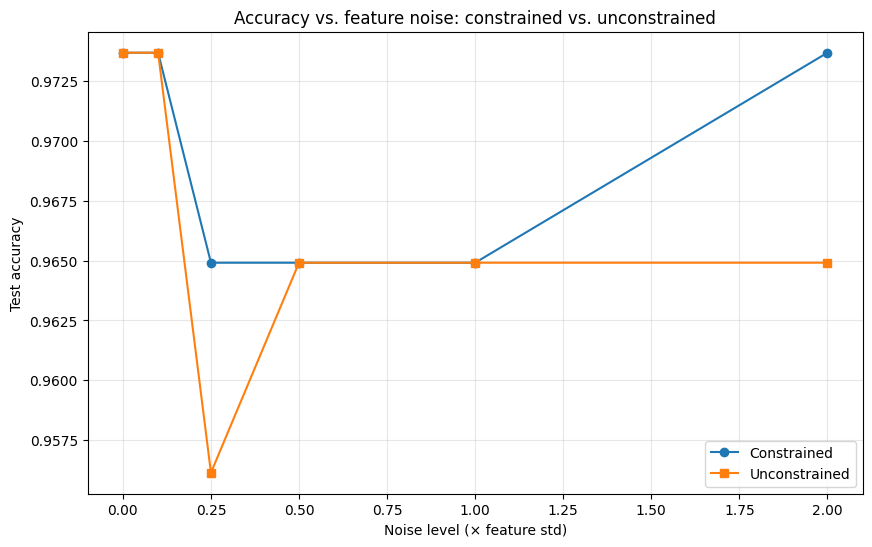

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(results_noise['level'], results_noise['constrained'], 'o-', label='Constrained')
plt.plot(results_noise['level'], results_noise['unconstrained'], 's-', label='Unconstrained')
plt.xlabel('Noise level (× feature std)')
plt.ylabel('Test accuracy')
plt.title('Accuracy vs. feature noise: constrained vs. unconstrained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('noise_robustness.png', dpi=150)